# D04 · Plan sample size from effects and precision

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PD02](../../curriculum/papers/design.md#pd02), [PD06](../../curriculum/papers/design.md#pd06).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** Why do the estimand, measurement reliability, and sampling plan matter alongside participant count?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

Power is the probability that a specified test rejects its null under a specified alternative and data-generating model. It is not the probability that a significant result is correct. A power calculation must name the effect, noise, sampling unit, dependence, test, threshold, and stopping rule. If those assumptions are optimistic, the numerical output will be optimistic too. A small pilot's largest effect is usually a poor single input for planning.

This notebook uses independent normal participant-level differences with standard deviation one. A difference of 0.3 is an arbitrary teaching effect, not a realistic effect imported from an imaging paper. We compare two-sided one-sample t tests at fixed participant counts. The noncentral t distribution supplies an analytical power value under these assumptions. Monte Carlo simulation then independently checks the formula. Agreement verifies the implementation for this generator; it does not establish that a real population follows the generator.

Precision is a second design goal. A narrow interval may be more informative than a binary detection decision when several effect sizes would be scientifically consequential. With known population standard deviation, the standard error of the sample mean is sigma/sqrt(n). In a real small sample sigma is estimated, and a t interval accounts for that uncertainty under its assumptions. Doubling n does not halve the standard error; quadrupling n does. Adding trials per person and adding independent people solve different components of the variance problem.

The number of simulated studies controls Monte Carlo accuracy, not the size of one hypothetical study. An estimated detection rate of 0.8 from 2,000 simulations has Monte Carlo standard error about 0.009. Report that numerical uncertainty alongside the design assumptions. Include plausible effect sizes near zero, not only a favorable effect. For voxelwise testing, actual correction and spatial dependence also matter; the uncorrected single-outcome planning exercise here cannot justify a whole-brain sample size.

Compute exact-model power and check its monotonicity for this fixed design.

n / power / ideal SE: [(np.int64(20), np.float64(0.247), np.float64(0.224)), (np.int64(40), np.float64(0.457), np.float64(0.158)), (np.int64(80), np.float64(0.755), np.float64(0.112)), (np.int64(160), np.float64(0.965), np.float64(0.079))]


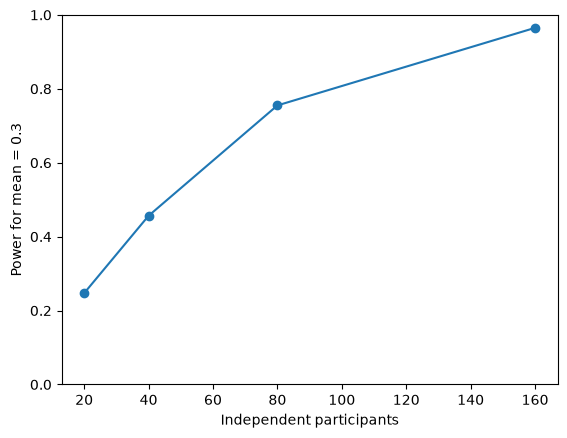

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
sizes = np.array([20, 40, 80, 160])
effect = 0.3
critical = stats.t.ppf(.975, sizes - 1)
ncp = effect * np.sqrt(sizes)
power = stats.nct.cdf(-critical, sizes - 1, ncp) + stats.nct.sf(critical, sizes - 1, ncp)
assert np.all(np.diff(power) > 0)
se = 1 / np.sqrt(sizes)
assert np.isclose(se[0] / se[2], 2)
print('n / power / ideal SE:', list(zip(sizes, power.round(3), se.round(3))))
plt.plot(sizes, power, marker='o'); plt.ylim(0, 1)
plt.xlabel('Independent participants'); plt.ylabel('Power for mean = 0.3'); plt.show()

Monte Carlo validation is another experiment, not more participants in the planned study.

In [2]:
rng = np.random.default_rng(204)
repetitions, n = 6000, 80
samples = rng.normal(effect, 1, size=(repetitions, n))
rejections = stats.ttest_1samp(samples, 0, axis=1).pvalue < .05
estimate = rejections.mean()
mc_se = np.sqrt(estimate * (1 - estimate) / repetitions)
assert abs(estimate - power[2]) < 5 * mc_se
null_samples = samples - effect
null_rate = (stats.ttest_1samp(null_samples, 0, axis=1).pvalue < .05).mean()
assert abs(null_rate - .05) < .02
print('Simulation / theoretical / MC SE / null rate:', estimate, power[2], mc_se, null_rate)

Simulation / theoretical / MC SE / null rate: 0.7545 0.7550840393499448 0.005556223987565657 0.04783333333333333


## Supervise the AI, then transfer the idea

**AI prompt:** “Before proposing a sample size, list every assumption in the noncentral-t calculation. Change the mean difference to 0.1, 0.3, and 0.5; keep noise, alpha, and stopping rule fixed. Explain which sample sizes meet a prespecified precision or power goal. Do not infer the true effect from whether my earlier p value was significant.”

**Deliberate mistake:** keep adding participants until the ordinary p value crosses 0.05. Explain that this is a different stopping procedure requiring different error control; do not silently present the fixed-n power as its justification. Transfer to research by specifying exclusions, attrition allowance, minimum interesting effect, multiplicity, and participant dependence before simulation. Deliver a sensitivity table and the reasons for the effect/noise range. If resources dictate n, report achievable precision and power honestly rather than reverse-engineering a favorable effect.

## Answer key — read after your own explanation

Power increases across these sample sizes for the fixed normal mean model. n=80 has half the ideal SE of n=20. The simulated power should agree with noncentral-t power within numerical simulation error; the null rejection rate stays near alpha. More simulations reduce MC error without improving the hypothetical study. A non-significant result is not proof of no meaningful effect, particularly when the interval is wide.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [Poldrack DesignEfficiency notebook](https://github.com/poldrack/fmri-analysis-vm/blob/d93fcf8e818c850d0a1b4e96b01ac987f27e9d34/analysis/efficiency/DesignEfficiency.ipynb) for sensitivity of designs; [MIT 9.07 lecture 10, Monte Carlo, and lecture 11, hypothesis testing](https://ocw.mit.edu/courses/9-07-statistics-for-brain-and-cognitive-science-fall-2016/pages/syllabus/); [Lakens, Sample Size Justification](https://doi.org/10.1525/collabra.33267). See [the coverage and gaps](../../curriculum/design_coverage.md).

### Return to the research question

Reopen [PD02](../../curriculum/papers/design.md#pd02), [PD06](../../curriculum/papers/design.md#pd06) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
